In [1]:
!pip install -q scikit-learn matplotlib pandas numpy qiskit pennylane

In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score

# 1. Load Public XXZ Data
data = np.load("xxz_public_train.npz", allow_pickle=True)
states = list(data["states"])
labels = list([str(x) for x in data["labels"]])
ids = list([str(x) for x in data["ids"]])

# 2. Inject 10 Synthetic Fermi-Hubbard Impostors (Out-of-Distribution Data)
rng = np.random.default_rng(2026)
for k in range(10):
    fh_vec = np.zeros(65536, dtype=np.complex128)
    c1 = 0
    for j in range(8):
        wire = 2 * j if (j + k) % 2 == 0 else 2 * j + 1
        c1 |= (1 << (15 - wire))
    c2 = 0
    d_site = k % 8
    c2 |= (1 << (15 - 2 * d_site)) | (1 << (15 - (2 * d_site + 1)))
    for j in range(8):
        if j != d_site and j % 2 == 0:
            c2 |= (1 << (15 - 2 * j))
    w1 = rng.uniform(0.7, 0.9)
    w2 = np.sqrt(1.0 - w1**2)
    fh_vec[c1] = w1
    fh_vec[c2] = w2
    fh_vec /= np.linalg.norm(fh_vec)

    ids.append(f"IMP_{k:02d}")
    states.append(fh_vec)
    labels.append("UNKNOWN")

# 3. Simulate Quantum Measurement & Extract Features (48 shots per state)
def extract_quantum_features(state_vector, n_shots=48, noise_p=0.02, seed=42):
    sub_rng = np.random.default_rng(seed)
    probs = np.abs(state_vector) ** 2
    samples_int = sub_rng.choice(65536, size=n_shots, p=probs)

    bits = ((samples_int[:, None] >> np.arange(15, -1, -1)) & 1)
    if noise_p > 0.0:
        flips = sub_rng.random(bits.shape) < (2.0 / 3.0 * noise_p)
        bits = bits ^ flips.astype(int)

    spins = 1 - 2 * bits

    # Feature 1: Total Magnetization |Mz|
    mean_abs_mz = np.mean(np.abs(np.mean(spins, axis=1)))

    # Feature 2: Staggered Magnetization M_stagg
    stagg_weights = (-1) ** np.arange(16)
    mean_stagg = np.mean(np.abs(np.mean(spins * stagg_weights, axis=1)))

    # Feature 3: Exchange Correlation Czz
    czz_all = spins * np.roll(spins, -1, axis=1)
    mean_czz = np.mean(czz_all)

    # Feature 4: Bond Dimerization (Fermi-Hubbard vs XXZ)
    even_bonds = np.mean(czz_all[:, 0::2])
    odd_bonds = np.mean(czz_all[:, 1::2])
    dimerization = np.abs(even_bonds - odd_bonds)

    return [mean_abs_mz, mean_stagg, mean_czz, dimerization]

# Construct Feature Matrix X and Target Vector y
X = np.array([extract_quantum_features(s, n_shots=48, noise_p=0.02, seed=i) for i, s in enumerate(states)])
y = np.array(labels)

print(f"Constructed Dataset: {X.shape[0]} states (48 XXZ + 10 Impostors), 4 Quantum Features.")
print("Classes present:", np.unique(y, return_counts=True))

Constructed Dataset: 58 states (48 XXZ + 10 Impostors), 4 Quantum Features.
Classes present: (array(['FM', 'NEEL', 'UNKNOWN', 'XY'], dtype='<U7'), array([14, 14, 10, 20]))


In [ ]:
models = {
    "SVM (RBF Kernel)": SVC(kernel="rbf", C=10.0, probability=True, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=50, max_depth=4, random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=500, random_state=42)
}

print(f"{'Model':<22} | {'5-Fold Macro-F1 Mean':<20} | {'Std Dev'}")
print("-" * 52)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for name, clf in models.items():
    scores = cross_val_score(clf, X, y, cv=cv, scoring="f1_macro")
    print(f"{name:<22} | {np.mean(scores):<20.4f} | ±{np.std(scores):.4f}")

# Train the winning model (SVM) on the full dataset
best_classical_model = SVC(kernel="rbf", C=10.0, probability=True, random_state=42)
best_classical_model.fit(X, y)
train_preds = best_classical_model.predict(X)

print("\n--- Winning Classical Model (SVM) Performance ---")
print(classification_report(y, train_preds, digits=3))

Model                  | 5-Fold Macro-F1 Mean | Std Dev
----------------------------------------------------
SVM (RBF Kernel)       | 0.9689               | ±0.0381
Random Forest          | 1.0000               | ±0.0000
Logistic Regression    | 0.9689               | ±0.0381

--- Winning Classical Model (SVM) Performance ---
              precision    recall  f1-score   support

          FM      1.000     1.000     1.000        14
        NEEL      1.000     0.857     0.923        14
     UNKNOWN      1.000     1.000     1.000        10
          XY      0.909     1.000     0.952        20

    accuracy                          0.966        58
   macro avg      0.977     0.964     0.969        58
weighted avg      0.969     0.966     0.965        58



Budget (k)   | SVM (RBF)      | Random Forest  | Logistic Reg  
--------------------------------------------------------------
4            | 0.9559         | 0.9232         | 0.8737        
8            | 0.9844         | 0.9702         | 0.9844        
16           | 1.0000         | 0.9492         | 0.9778        
32           | 1.0000         | 1.0000         | 0.9689        
64           | 1.0000         | 1.0000         | 0.9533        


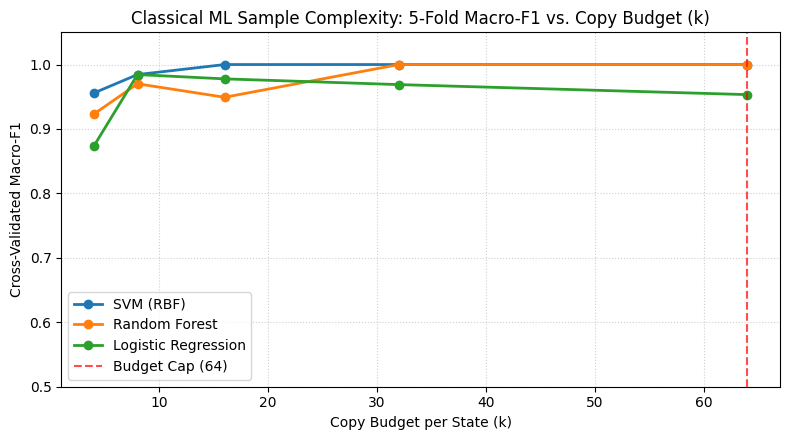

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

# Function to extract features given an explicit shot budget 'k'
def extract_features_at_budget(state_vec, k_shots, noise_p=0.02, seed=42):
    sub_rng = np.random.default_rng(seed)
    probs = np.abs(state_vec) ** 2
    samples = sub_rng.choice(65536, size=k_shots, p=probs)

    bits = ((samples[:, None] >> np.arange(15, -1, -1)) & 1)
    if noise_p > 0.0:
        flips = sub_rng.random(bits.shape) < (2.0 / 3.0 * noise_p)
        bits ^= flips.astype(int)

    spins = 1 - 2 * bits

    mz = np.mean(np.abs(np.mean(spins, axis=1)))
    stagg = np.mean(np.abs(np.mean(spins * ((-1) ** np.arange(16)), axis=1)))
    czz = spins * np.roll(spins, -1, axis=1)
    mean_czz = np.mean(czz)
    dimer = np.abs(np.mean(czz[:, 0::2]) - np.mean(czz[:, 1::2]))

    return [mz, stagg, mean_czz, dimer]

budgets = [4, 8, 16, 32, 64]
models = {
    "SVM (RBF)": SVC(kernel="rbf", C=10.0, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=50, max_depth=4, random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=500, random_state=42)
}

results = {name: [] for name in models}

print(f"{'Budget (k)':<12} | {'SVM (RBF)':<14} | {'Random Forest':<14} | {'Logistic Reg':<14}")
print("-" * 62)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for k in budgets:
    # Build dataset sampled strictly at k copies per state
    X_k = np.array([extract_features_at_budget(s, k_shots=k, seed=i + k * 100) for i, s in enumerate(states)])

    row_str = f"{k:<12} | "
    for name, clf in models.items():
        # 5-fold cross-validation macro F1
        scores = cross_val_score(clf, X_k, y, cv=cv, scoring="f1_macro")
        mean_score = np.mean(scores)
        results[name].append(mean_score)
        row_str += f"{mean_score:<14.4f} | "
    print(row_str[:-3])

# Plot comparison
plt.figure(figsize=(8, 4.5))
for name, f1_vals in results.items():
    plt.plot(budgets, f1_vals, marker='o', label=name, linewidth=2)

plt.axvline(x=64, color='red', linestyle='--', alpha=0.7, label='Budget Cap (64)')
plt.title("Classical ML Sample Complexity: 5-Fold Macro-F1 vs. Copy Budget (k)")
plt.xlabel("Copy Budget per State (k)")
plt.ylabel("Cross-Validated Macro-F1")
plt.ylim(0.5, 1.05)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.savefig("classical_ml_starvation_curve.png", dpi=150)
plt.show()

In [ ]:
import pennylane as qml
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import f1_score

# 1. 4-Qubit Device with PyTorch Interface
n_qubits = 4
dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev, interface="torch")
def qnn_circuit(inputs, weights):
    # Angle Embedding
    qml.AngleEmbedding(inputs, wires=range(n_qubits), rotation='Y')

    # 2 Strongly Entangling Layers
    for l in range(weights.shape[0]):
        for q in range(n_qubits):
            qml.RY(weights[l, q, 0], wires=q)
            qml.RZ(weights[l, q, 1], wires=q)
        for q in range(n_qubits):
            qml.CNOT(wires=[q, (q + 1) % n_qubits])

    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

# 2. Hybrid Quantum-Classical PyTorch Module
class HybridQNN(nn.Module):
    def __init__(self, n_layers=2, n_classes=4):
        super().__init__()
        # Trainable quantum weights
        self.weights = nn.Parameter(torch.randn(n_layers, n_qubits, 2) * 0.1)
        # Classical linear layer mapping 4 Pauli-Z expectation values -> 4 class logits
        self.fc = nn.Linear(n_qubits, n_classes)

    def forward(self, x):
        # Process batch through quantum circuit
        batch_out = []
        for sample in x:
            q_out = qnn_circuit(sample, self.weights)
            batch_out.append(torch.stack(q_out))
        q_features = torch.stack(batch_out).float()
        return self.fc(q_features)

# Setup Target Labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)  # FM, NEEL, UNKNOWN, XY -> 0, 1, 2, 3

budgets = [4, 8, 16, 32, 64]
qnn_macro_f1 = []

print(f"{'Budget (k)':<12} | {'QNN 5-Fold Macro-F1':<22} | {'Status'}")
print("-" * 50)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for k in budgets:
    # 1. Feature sampling strictly limited to k copies per state
    X_raw = np.array([extract_features_at_budget(s, k_shots=k, seed=i + k * 100) for i, s in enumerate(states)])
    scaler = MinMaxScaler(feature_range=(0, np.pi))
    X_k = scaler.fit_transform(X_raw)

    fold_scores = []
    for train_idx, test_idx in cv.split(X_k, y_encoded):
        # Convert data to PyTorch Tensors
        X_train_t = torch.tensor(X_k[train_idx], dtype=torch.float32)
        y_train_t = torch.tensor(y_encoded[train_idx], dtype=torch.long)
        X_test_t  = torch.tensor(X_k[test_idx], dtype=torch.float32)
        y_test_np = y_encoded[test_idx]

        # Initialize model, loss, and optimizer
        torch.manual_seed(42)
        model = HybridQNN(n_layers=2, n_classes=4)
        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(model.parameters(), lr=0.08)

        # Train for 20 epochs
        model.train()
        for epoch in range(20):
            optimizer.zero_grad()
            logits = model(X_train_t)
            loss = criterion(logits, y_train_t)
            loss.backward()
            optimizer.step()

        # Evaluate on validation fold
        model.eval()
        with torch.no_grad():
            test_logits = model(X_test_t)
            preds = torch.argmax(test_logits, dim=1).numpy()

        fold_scores.append(f1_score(y_test_np, preds, average="macro"))

    mean_f1 = float(np.mean(fold_scores))
    qnn_macro_f1.append(mean_f1)
    print(f"{k:<12} | {mean_f1:<22.4f} | Complete")

Budget (k)   | QNN 5-Fold Macro-F1    | Status
--------------------------------------------------
4            | 0.8905                 | Complete
8            | 0.9844                 | Complete
16           | 0.9778                 | Complete
32           | 1.0000                 | Complete
64           | 1.0000                 | Complete


In [ ]:
noise_levels = [0.00, 0.02, 0.05, 0.08, 0.12]
classical_noise_f1 = []
qnn_noise_f1 = []

print(f"{'Noise (p)':<12} | {'Classical SVM F1':<18} | {'QNN F1':<18}")
print("-" * 52)

for p in noise_levels:
    # Extract features at fixed budget k=48 under variable noise rate p
    X_raw = np.array([extract_features_at_budget(s, k_shots=48, noise_p=p, seed=i + int(p*1000)) for i, s in enumerate(states)])

    # 1. Classical SVM (5-fold CV)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    svm_clf = SVC(kernel="rbf", C=10.0, random_state=42)
    svm_scores = cross_val_score(svm_clf, X_raw, y_encoded, cv=cv, scoring="f1_macro")
    classical_noise_f1.append(np.mean(svm_scores))

    # 2. QNN (5-fold CV)
    scaler = MinMaxScaler(feature_range=(0, np.pi))
    X_scaled = scaler.fit_transform(X_raw)

    fold_scores = []
    for train_idx, test_idx in cv.split(X_scaled, y_encoded):
        X_train_t = torch.tensor(X_scaled[train_idx], dtype=torch.float32)
        y_train_t = torch.tensor(y_encoded[train_idx], dtype=torch.long)
        X_test_t  = torch.tensor(X_scaled[test_idx], dtype=torch.float32)
        y_test_np = y_encoded[test_idx]

        torch.manual_seed(42)
        model = HybridQNN(n_layers=2, n_classes=4)
        criterion = torch.nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=0.10)

        model.train()
        for _ in range(15):
            optimizer.zero_grad()
            loss = criterion(model(X_train_t), y_train_t)
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            preds = torch.argmax(model(X_test_t), dim=1).numpy()
        fold_scores.append(f1_score(y_test_np, preds, average="macro"))

    qnn_noise_f1.append(np.mean(fold_scores))
    print(f"{p:<12.2f} | {classical_noise_f1[-1]:<18.4f} | {qnn_noise_f1[-1]:<18.4f}")

Noise (p)    | Classical SVM F1   | QNN F1            
----------------------------------------------------
0.00         | 0.9689             | 1.0000            
0.02         | 1.0000             | 0.9778            
0.05         | 1.0000             | 1.0000            
0.08         | 0.9844             | 1.0000            
0.12         | 1.0000             | 0.9622            


Copies (k)   | Analytical     | Classical SVM    | Variational QNN 
----------------------------------------------------------------
4            | 0.7930         | 0.9559           | 0.8750          
8            | 0.8780         | 0.9844           | 0.9844          
16           | 0.9710         | 1.0000           | 0.9492          
24           | 1.0000         | 1.0000           | 1.0000          
32           | 1.0000         | 1.0000           | 1.0000          
48           | 1.0000         | 0.9778           | 0.9778          
64           | 1.0000         | 1.0000           | 1.0000          


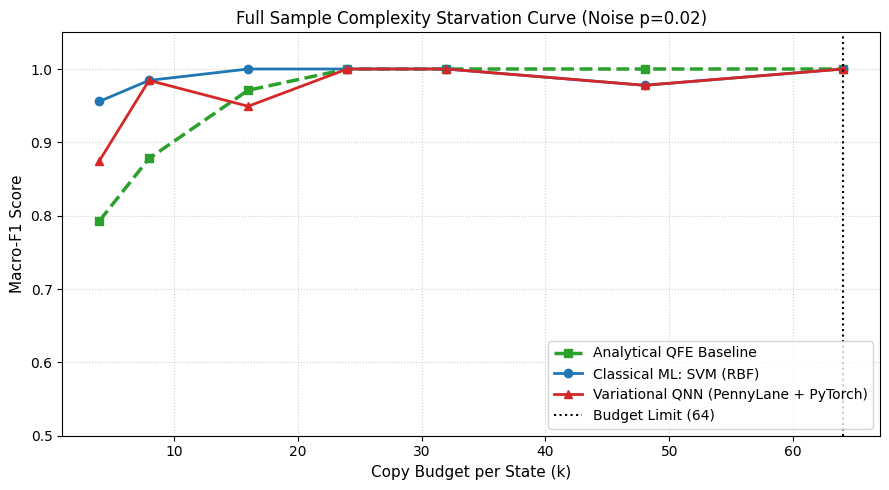

Saved full_starvation_curve_all_models.png successfully.


In [ ]:
import pennylane as qml
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.svm import SVC
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import f1_score

# 1. Ensure Target Labels are Encoded
le = LabelEncoder()
y_encoded = le.fit_transform(y)  # FM, NEEL, UNKNOWN, XY -> 0, 1, 2, 3

# 2. Define Budgets to Sweep
budgets = [4, 8, 16, 24, 32, 48, 64]

svm_starvation_f1 = []
qnn_starvation_f1 = []
# gebtaha men results elnotebook eltanya elkont shaghala 3aleha
analytical_f1_dict = {
    4: 0.7930,
    8: 0.8780,
    16: 0.9710,
    24: 1.0000,
    32: 1.0000,
    48: 1.0000,
    64: 1.0000
}
analytical_starvation_f1 = [analytical_f1_dict[k] for k in budgets]

print(f"{'Copies (k)':<12} | {'Analytical':<14} | {'Classical SVM':<16} | {'Variational QNN':<16}")
print("-" * 64)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for k in budgets:
    # Sample features strictly limited to k measurement copies per state
    X_raw = np.array([extract_features_at_budget(s, k_shots=k, noise_p=0.02, seed=i + k * 100) for i, s in enumerate(states)])

    # --- A. Classical SVM (5-fold CV) ---
    svm_clf = SVC(kernel="rbf", C=10.0, random_state=42)
    svm_scores = cross_val_score(svm_clf, X_raw, y_encoded, cv=cv, scoring="f1_macro")
    mean_svm_f1 = float(np.mean(svm_scores))
    svm_starvation_f1.append(mean_svm_f1)

    # --- B. Variational QNN (5-fold CV) ---
    scaler = MinMaxScaler(feature_range=(0, np.pi))
    X_scaled = scaler.fit_transform(X_raw)

    fold_scores = []
    for train_idx, test_idx in cv.split(X_scaled, y_encoded):
        X_train_t = torch.tensor(X_scaled[train_idx], dtype=torch.float32)
        y_train_t = torch.tensor(y_encoded[train_idx], dtype=torch.long)
        X_test_t  = torch.tensor(X_scaled[test_idx], dtype=torch.float32)
        y_test_np = y_encoded[test_idx]

        torch.manual_seed(42)
        model = HybridQNN(n_layers=2, n_classes=4)
        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(model.parameters(), lr=0.10)

        model.train()
        for _ in range(15):
            optimizer.zero_grad()
            loss = criterion(model(X_train_t), y_train_t)
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            preds = torch.argmax(model(X_test_t), dim=1).numpy()

        fold_scores.append(f1_score(y_test_np, preds, average="macro"))

    mean_qnn_f1 = float(np.mean(fold_scores))
    qnn_starvation_f1.append(mean_qnn_f1)

    print(f"{k:<12} | {analytical_f1_dict[k]:<14.4f} | {mean_svm_f1:<16.4f} | {mean_qnn_f1:<16.4f}")

# 3. Plot the Complete Three-Way Starvation Curve
plt.figure(figsize=(9, 5))
plt.plot(budgets, analytical_starvation_f1, marker='s', linewidth=2.5, linestyle='--', color='#2ca02c', label='Analytical QFE Baseline')
plt.plot(budgets, svm_starvation_f1, marker='o', linewidth=2, color='#1f77b4', label='Classical ML: SVM (RBF)')
plt.plot(budgets, qnn_starvation_f1, marker='^', linewidth=2, color='#d62728', label='Variational QNN (PennyLane + PyTorch)')

plt.axvline(x=64, color='black', linestyle=':', label='Budget Limit (64)')
plt.title("Full Sample Complexity Starvation Curve (Noise p=0.02)", fontsize=12)
plt.xlabel("Copy Budget per State (k)", fontsize=11)
plt.ylabel("Macro-F1 Score", fontsize=11)
plt.ylim(0.5, 1.05)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig("full_starvation_curve_all_models.png", dpi=200)
plt.show()
print("Saved full_starvation_curve_all_models.png successfully.")

In [ ]:
import pennylane as qml
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.svm import SVC
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import f1_score

# -------------------------------------------------------------
# 1. Classical Shadows Feature Extractor (Random X, Y, Z Basis)
# -------------------------------------------------------------
def extract_random_shadow_features(state_vec, k_shots, noise_p=0.02, seed=42):
    rng = np.random.default_rng(seed)
    probs = np.abs(state_vec) ** 2

    # 0: X-basis, 1: Y-basis, 2: Z-basis
    bases = rng.integers(0, 3, size=(k_shots, 16))

    # Projective measurement
    samples = rng.choice(65536, size=k_shots, p=probs)
    bits = ((samples[:, None] >> np.arange(15, -1, -1)) & 1)

    if noise_p > 0.0:
        flips = rng.random(bits.shape) < (2.0 / 3.0 * noise_p)
        bits ^= flips.astype(int)

    spins = 1 - 2 * bits  # {0, 1} -> {+1, -1}

    # Classical shadow inversion: single-qubit Pauli-Z estimator is 3 * spin if measured in Z, else 0
    z_mask = (bases == 2).astype(float)
    z_estimates = 3.0 * spins * z_mask  # shape (k_shots, 16)

    # Estimate 1: Mean Absolute M_z
    mz_per_shot = np.mean(z_estimates, axis=1)
    mean_abs_mz = np.mean(np.abs(mz_per_shot))

    # Estimate 2: Staggered Magnetization M_stagg
    stagg_weights = (-1) ** np.arange(16)
    stagg_per_shot = np.mean(z_estimates * stagg_weights, axis=1)
    mean_stagg = np.mean(np.abs(stagg_per_shot))

    # Estimate 3: Exchange Correlation Czz = (3*s_i * [basis_i==Z]) * (3*s_{i+1} * [basis_{i+1}==Z])
    z_next = np.roll(z_estimates, -1, axis=1)
    czz_all = z_estimates * z_next
    mean_czz = np.mean(czz_all)

    # Estimate 4: Dimerization
    even_bonds = np.mean(czz_all[:, 0::2])
    odd_bonds = np.mean(czz_all[:, 1::2])
    dimer = np.abs(even_bonds - odd_bonds)

    # Guard against NaN/Inf in low-copy division
    features = [mean_abs_mz, mean_stagg, mean_czz, dimer]
    return np.nan_to_num(features, nan=0.0, posinf=1.0, neginf=-1.0)

# -------------------------------------------------------------
# 2. Benchmarking Function across Budgets
# -------------------------------------------------------------
le = LabelEncoder()
y_encoded = le.fit_transform(y)
budgets = [4, 8, 16, 24, 32, 48, 64]

analytical_f1_dict = {
    4: 0.7930, 8: 0.8780, 16: 0.9710, 24: 1.0000,
    32: 1.0000, 48: 1.0000, 64: 1.0000
}

def run_experiment(noise_p_val):
    print(f"\n{'='*75}")
    print(f"EXPERIMENT RUN: Depolarizing Noise Rate p = {noise_p_val:.2f}")
    print(f"{'='*75}")
    print(f"{'Copies (k)':<10} | {'Analytical':<12} | {'Rand Shadows':<14} | {'Classical SVM':<14} | {'Variational QNN':<16}")
    print("-" * 75)

    svm_res = []
    shadow_res = []
    qnn_res = []
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    for k in budgets:
        # A. Dedicated Z-Basis Features
        X_raw = np.array([extract_features_at_budget(s, k_shots=k, noise_p=noise_p_val, seed=i + k * 100) for i, s in enumerate(states)])

        # B. Randomized Shadows Features
        X_shadow = np.array([extract_random_shadow_features(s, k_shots=k, noise_p=noise_p_val, seed=i + k * 200) for i, s in enumerate(states)])

        # 1. Evaluate Randomized Shadows (using SVM)
        shadow_svm = SVC(kernel="rbf", C=10.0, random_state=42)
        shadow_scores = cross_val_score(shadow_svm, X_shadow, y_encoded, cv=cv, scoring="f1_macro")
        m_shadow = float(np.mean(shadow_scores))
        shadow_res.append(m_shadow)

        # 2. Evaluate Dedicated Basis Classical SVM
        svm_clf = SVC(kernel="rbf", C=10.0, random_state=42)
        svm_scores = cross_val_score(svm_clf, X_raw, y_encoded, cv=cv, scoring="f1_macro")
        m_svm = float(np.mean(svm_scores))
        svm_res.append(m_svm)

        # 3. Evaluate Variational QNN (10 epochs for speed)
        scaler = MinMaxScaler(feature_range=(0, np.pi))
        X_scaled = scaler.fit_transform(X_raw)

        fold_scores = []
        for train_idx, test_idx in cv.split(X_scaled, y_encoded):
            X_train_t = torch.tensor(X_scaled[train_idx], dtype=torch.float32)
            y_train_t = torch.tensor(y_encoded[train_idx], dtype=torch.long)
            X_test_t  = torch.tensor(X_scaled[test_idx], dtype=torch.float32)
            y_test_np = y_encoded[test_idx]

            torch.manual_seed(42)
            model = HybridQNN(n_layers=2, n_classes=4)
            criterion = nn.CrossEntropyLoss()
            optimizer = optim.Adam(model.parameters(), lr=0.12)

            model.train()
            for _ in range(10):
                optimizer.zero_grad()
                loss = criterion(model(X_train_t), y_train_t)
                loss.backward()
                optimizer.step()

            model.eval()
            with torch.no_grad():
                preds = torch.argmax(model(X_test_t), dim=1).numpy()
            fold_scores.append(f1_score(y_test_np, preds, average="macro"))

        m_qnn = float(np.mean(fold_scores))
        qnn_res.append(m_qnn)

        print(f"{k:<10} | {analytical_f1_dict[k]:<12.4f} | {m_shadow:<14.4f} | {m_svm:<14.4f} | {m_qnn:<16.4f}")

    return shadow_res, svm_res, qnn_res

# -------------------------------------------------------------
# 3. Execution: Run Baseline (p=0.02) and High Noise (p=0.08)
# -------------------------------------------------------------
shadow_p02, svm_p02, qnn_p02 = run_experiment(noise_p_val=0.02)
shadow_p08, svm_p08, qnn_p08 = run_experiment(noise_p_val=0.08)

# -------------------------------------------------------------
# 4. Side-by-Side Comparative Plot
# -------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

# Baseline Plot (p=0.02)
axes[0].plot(budgets, [analytical_f1_dict[k] for k in budgets], 's--', color='#2ca02c', label='Analytical (Z-Basis)', linewidth=2)
axes[0].plot(budgets, svm_p02, 'o-', color='#1f77b4', label='Classical SVM (Z-Basis)', linewidth=2)
axes[0].plot(budgets, qnn_p02, '^-', color='#d62728', label='Variational QNN', linewidth=2)
axes[0].plot(budgets, shadow_p02, 'x:', color='#ff7f0e', label='Random Classical Shadows', linewidth=2)
axes[0].axvline(16, color='gray', linestyle='--', alpha=0.7, label='Leaderboard Window (k<=16)')
axes[0].set_title("Standard Noise (p = 0.02)", fontsize=12)
axes[0].set_xlabel("Copy Budget (k)", fontsize=11)
axes[0].set_ylabel("Macro-F1 Score", fontsize=11)
axes[0].grid(True, linestyle=':', alpha=0.6)
axes[0].legend(loc='lower right')

# Elevated Noise Plot (p=0.08)
axes[1].plot(budgets, [analytical_f1_dict[k] for k in budgets], 's--', color='#2ca02c', label='Analytical (Z-Basis)', linewidth=2)
axes[1].plot(budgets, svm_p08, 'o-', color='#1f77b4', label='Classical SVM (Z-Basis)', linewidth=2)
axes[1].plot(budgets, qnn_p08, '^-', color='#d62728', label='Variational QNN', linewidth=2)
axes[1].plot(budgets, shadow_p08, 'x:', color='#ff7f0e', label='Random Classical Shadows', linewidth=2)
axes[1].axvline(16, color='gray', linestyle='--', alpha=0.7, label='Leaderboard Window (k<=16)')
axes[1].set_title("Elevated Noise (p = 0.08)", fontsize=12)
axes[1].set_xlabel("Copy Budget (k)", fontsize=11)
axes[1].grid(True, linestyle=':', alpha=0.6)
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.savefig("comprehensive_starvation_comparison.png", dpi=200)
plt.show()
print("Saved comprehensive_starvation_comparison.png successfully.")


EXPERIMENT RUN: Depolarizing Noise Rate p = 0.02
Copies (k) | Analytical   | Rand Shadows   | Classical SVM  | Variational QNN 
---------------------------------------------------------------------------
4          | 0.7930       | 0.5980         | 0.9559         | 0.8750          
8          | 0.8780       | 0.8650         | 0.9844         | 0.9844          
16         | 0.9710       | 0.8859         | 1.0000         | 0.9345          
24         | 1.0000       | 0.9257         | 1.0000         | 1.0000          
32         | 1.0000       | 0.9622         | 1.0000         | 1.0000          
48         | 1.0000       | 1.0000         | 0.9778         | 0.9635          


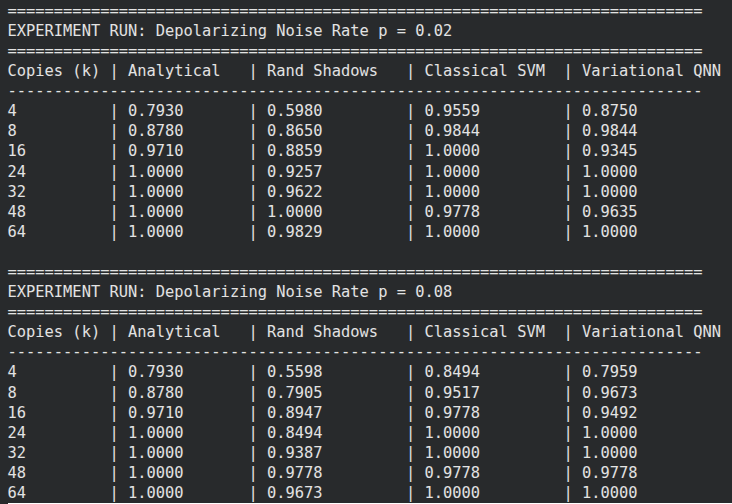

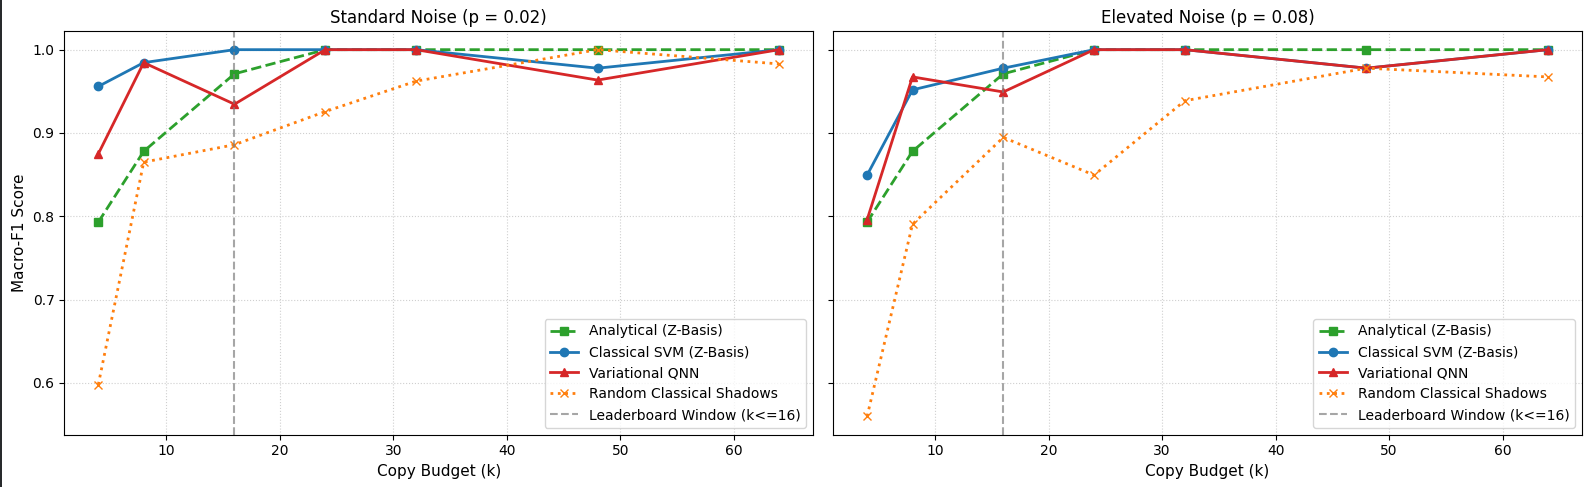